***Machine Learning Assignment***
# Predicitng Kenyan Financial Situations
**Done by Junaid, Clyde, Vinit, and Lee**
The basis of this project is to use data from 20,871 Kenyan adults surveyed in 2024 to build a machine learning model that can predict whether a person's financial situation has improved, stayed the same, or worsened, as well as identifying the key factors that drive the financial outcomes in Kenya.

## Table of Contents
- [Project Phases](#project-phases)
- [Data Acquisition](#data-acquisition)
- [Data Preprocessing](#data-preprocessing)
    - [Handling Outliers](#handling-outliers)
    - [Feature Encoding](#feature-encoding)
- [Feature Selection](#feature-selection)
- [Model Validation and Testing](#model-validation-and-testing)
- [Data visualization](#data-visualization)

## Project Phases
The project is broken down into the following phases:
1. Data acquisition: the dataset is sourced from Kaggle [https://www.kaggle.com/datasets/davidpbriggs/kenya-finaccess-household-survey-2024](https://www.kaggle.com/datasets/davidpbriggs/kenya-finaccess-household-survey-2024)
2. Data cleaning and preprocessing: missing values are handled, and non-numeric features are encoded for use in models
3. Feature selection: specific features are selected to use during training, primarily through Lasso (L1) regression
4. Model selection and testing: a model (either SVM, ANN, or decision trees) is chosen to use, and it is tested with the data
5. Data visualization: the results of the data and any findings are visualized for presentation

## Data Acquisition
As mentioned before, the data has been pulled from Kaggle: [https://www.kaggle.com/datasets/davidpbriggs/kenya-finaccess-household-survey-2024](https://www.kaggle.com/datasets/davidpbriggs/kenya-finaccess-household-survey-2024). A copy of the dataset it saved within the repository as well.

## Data Preprocessing
This is the first stage of the project. We import the dataset and get a summary of the columns and data we're dealing with.  
From there, we handle any missing values and encode the data for usage in models.

In [66]:
import pandas as pd

# Load the dataset
df = pd.read_excel('finaccess2024_datasprint.xlsx')

print(df.shape)

df.head()

(20871, 28)


,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,...,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,NaN,Without Disability
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,...,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,...,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability
3,Kiambu,Urban,Male,18-25,1,"""Some secondary""",Single/Never Married,10000,Usage,Non-usage,...,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability
4,Murang'a,Urban,Female,18-25,1,Some technical training after secondary school,Single/Never Married,10000,Usage,Non-usage,...,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,NaN,Without Disability


In [67]:
# Locate any columns with missing data
df.isna().sum()

county                      0
location_type               0
Sex                         0
Age                         0
household_size              0
education_level             0
marital_status              0
monthly_income              0
Savings_formal              0
Savings_informal            0
Loan_formal                 0
Loan_informal               0
defaulted                   0
formal_service_use          0
mobile_money_access         0
barriers_mobile_money       0
mobile_ownership_1          0
experienced_shock           0
nfhi_11                     0
nfhi_12                     0
nfhi_13                     0
accessto_13k_1month         0
not_difficult               0
financial_status            0
fl_score                    0
prodsum1                    0
barriers_bank            5734
has_disability              0
dtype: int64

From the above, we can see only one column has missing values: `barriers_bank`.  
`barriers_bank` indicates what barriers a person might have when accessing a bank, such as not being able to afford it, being illegible, difficult access, and so on. We can substitute the missing values with the text `No Barriers` as that makes the most sense.


In [68]:
df.fillna(value={"barriers_bank": "No barrier"}, inplace=True)

print(f"NaN values present in full dataset: {df.isna().sum().sum()}")

df.head()

NaN values present in full dataset: 0


,county,location_type,Sex,Age,household_size,education_level,marital_status,monthly_income,Savings_formal,Savings_informal,...,nfhi_11,nfhi_12,nfhi_13,accessto_13k_1month,not_difficult,financial_status,fl_score,prodsum1,barriers_bank,has_disability
0,Garissa,Urban,Female,26-35,5,Completed technical training after secondary s...,Married/Living with partner,30000,Non-usage,Non-usage,...,Yes,Yes,Yes,Yes,No,Stayed the same,All correct,3,No barrier,Without Disability
1,Garissa,Urban,Female,Above 55,11,"""None """,Married/Living with partner,10000,Non-usage,Non-usage,...,No,No,Yes,No,No,Worsened,Two correct,1,Affordability,Without Disability
2,Busia,Urban,Female,26-35,2,"""Primary completed""",Divorced/separated,3000,Usage,Usage,...,Yes,No,No,No,No,Improved,All correct,5,Affordability,Without Disability
3,Kiambu,Urban,Male,18-25,1,"""Some secondary""",Single/Never Married,10000,Usage,Non-usage,...,No,No,No,Yes,No,Improved,All correct,4,Affordability,Without Disability
4,Murang'a,Urban,Female,18-25,1,Some technical training after secondary school,Single/Never Married,10000,Usage,Non-usage,...,Yes,Yes,Yes,Yes,Yes,Improved,All correct,5,No barrier,Without Disability


Let's also look out for any mixed data types in the columns.

In [69]:
# Find mixed data types
for column in df.columns:
    col_type = pd.api.types.infer_dtype(df[column])
    if "mixed" in col_type:
        print(f"{column}: {col_type}")

df[['education_level', 'barriers_mobile_money']].head()

education_level: mixed-integer
barriers_mobile_money: mixed-integer


,education_level,barriers_mobile_money
0,Completed technical training after secondary s...,0
1,"""None """,0
2,"""Primary completed""",0
3,"""Some secondary""",0
4,Some technical training after secondary school,0


From the above, we can see that the `education_level` and `barriers_mobile_money` have mixed data types, most likely integers mixed in with the string values.

For the `education_level`, we can remove any columns with an integer in them, as that's probably an outlier. For `barriers_mobile_money`, we can convert all cells with a `0` to `No barriers`, similar to the `bank_barriers` column.

In [70]:
# Handle the education_level column
education_col = df['education_level']
num = pd.to_numeric(education_col, errors='coerce')
is_int = num.notna() & (num % 1 == 0)
df = df.loc[~is_int]

# Handle the barriers_mobile_money column
df.loc[df['barriers_mobile_money'] == 0, 'barriers_mobile_money'] = 'No barrier'

print(df.shape)

df[['education_level', 'barriers_mobile_money']].head()

(20869, 28)


,education_level,barriers_mobile_money
0,Completed technical training after secondary s...,No barrier
1,"""None """,No barrier
2,"""Primary completed""",No barrier
3,"""Some secondary""",No barrier
4,Some technical training after secondary school,No barrier


The marital status columns also has two values we need to remove from the dataset:
- Don't know   (DO NOT READ OUT)
- Refused to Answer(DO NOT READ OUT)

Some people also didn't answer what education level they're in, so we should remove that as well.

In [71]:
invalid_rows = df[
    (df['marital_status'].isin(["Don't know   (DO NOT READ OUT)", "Refused to Answer(DO NOT READ OUT)"])) 
    | (df['education_level'] == "\"Refused to Answer (DO NOT READ OUT)\"")
    ].index
df.drop(invalid_rows, inplace=True)

print(df.shape)

# Get the number of unique values in each column
df.nunique()

(20857, 28)


county                    47
location_type              2
Sex                        2
Age                        6
household_size            20
education_level           11
marital_status             4
monthly_income           236
Savings_formal             2
Savings_informal           2
Loan_formal                2
Loan_informal              2
defaulted                  2
formal_service_use         2
mobile_money_access        2
barriers_mobile_money     10
mobile_ownership_1         2
experienced_shock          2
nfhi_11                    2
nfhi_12                    2
nfhi_13                    2
accessto_13k_1month        2
not_difficult              2
financial_status           3
fl_score                   4
prodsum1                  23
barriers_bank             10
has_disability             2
dtype: int64

### Handling Outliers
There are some outliers present in the monthly income. Let's try remove them.

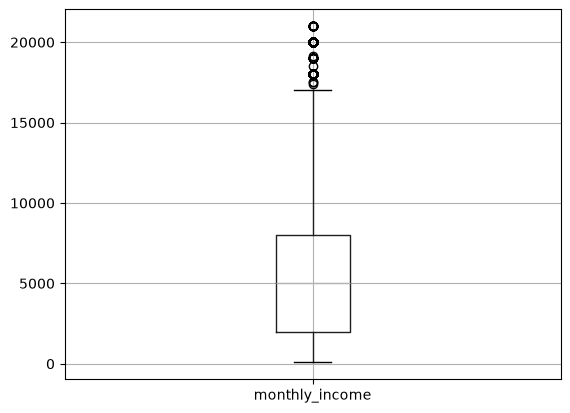

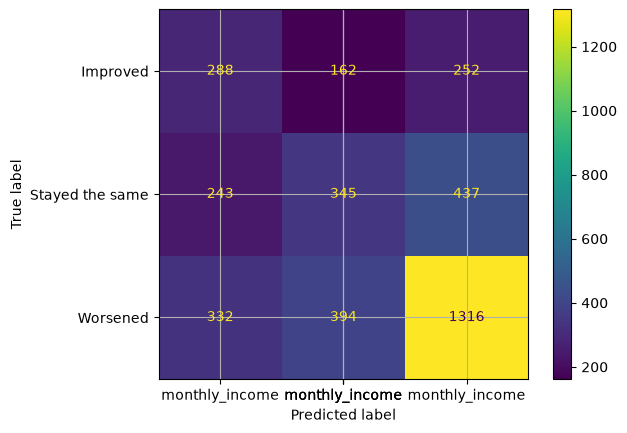

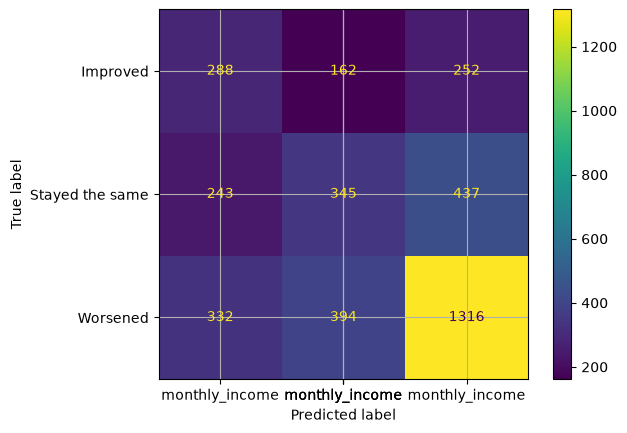

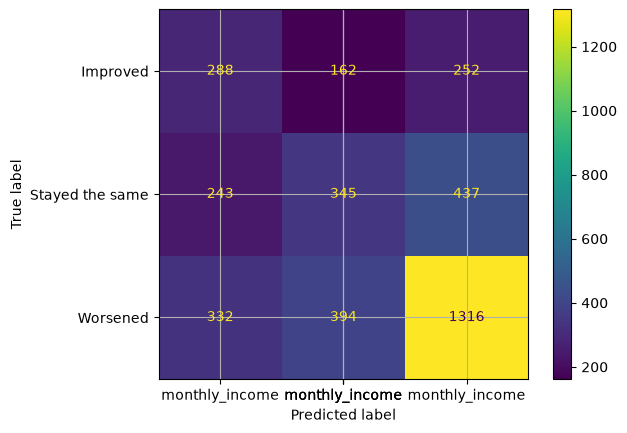

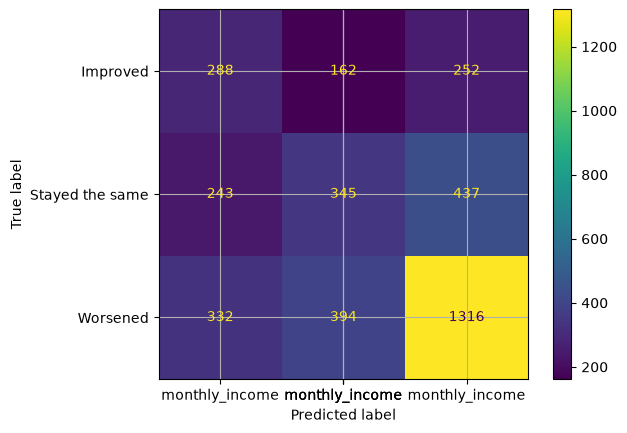

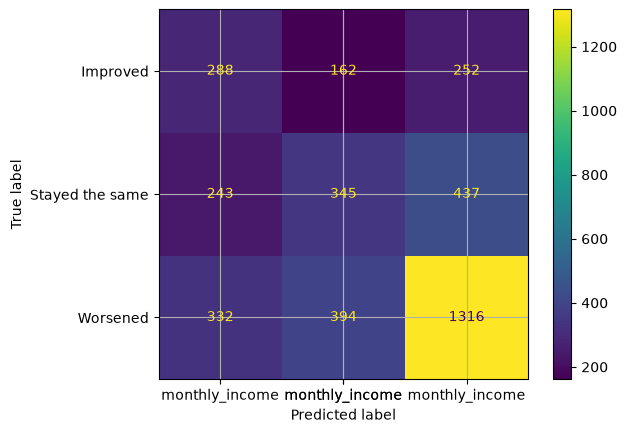

In [72]:
import matplotlib.pyplot as plt

# Let's visualize the outliers
df.boxplot(column=["monthly_income"])
plt.show()

(18842, 28)


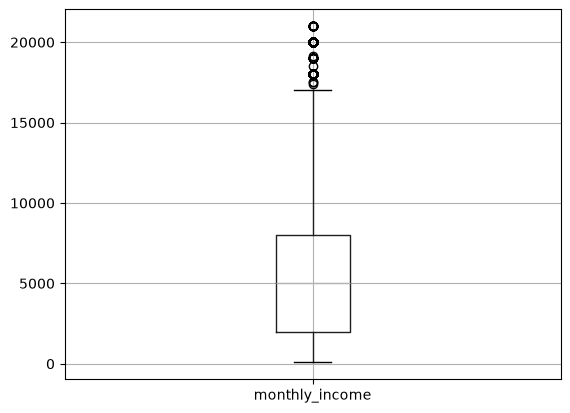

In [73]:
from matplotlib.cbook import boxplot_stats

stats = boxplot_stats(df["monthly_income"])
threshold_hi = stats[0]["whishi"]
threshold_lo = stats[0]["whislo"]

outliers_high = df[df["monthly_income"] > threshold_hi].index
df.drop(outliers_high, inplace=True)
outliers_low = df[df["monthly_income"] < threshold_lo].index
df.drop(outliers_low, inplace=True)


print(df.shape)
df.boxplot(column=["monthly_income"])
plt.show()

### Feature Encoding
We can now setup a column transformer using Scikit-Learn to handle encoding the data and preprocessing it.

For all columns which have two or more unique values (excluding the county, prodsum1, and fl_score), we'll use one-hot encoding.

Counties will be encoded using a target encoder. FL_score will use label encoding, as well as financial situation.

In [74]:
one_hot_cols = [
    'location_type',
    'Sex',
    'Age',
    'education_level',
    'marital_status',
    'Savings_formal',
    'Savings_informal',
    'Loan_formal',
    'Loan_informal',
    'defaulted',
    'formal_service_use',
    'mobile_money_access',
    'mobile_ownership_1',
    'experienced_shock',
    'nfhi_11',
    'nfhi_12',
    'nfhi_13',
    'accessto_13k_1month',
    'not_difficult',
    'has_disability'
]
"""Columns to be one-hot encoded"""

target_cols = ['county', 'barriers_mobile_money', 'barriers_bank']
"""Columns to be encoded using TargetEncoder"""

num_cols = ['household_size', 'monthly_income']
"""Columns to be scaled using StandardScaler"""

'Columns to be scaled using StandardScaler'

In [75]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, TargetEncoder, OrdinalEncoder, StandardScaler
from category_encoders import BinaryEncoder

RANDOM_STATE=42

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), one_hot_cols),
        ("ord", OrdinalEncoder(categories=[['None correct', 'One correct', 'Two correct', 'All correct']]), ['fl_score']),
        ("num", StandardScaler(), num_cols),
        ("county_te", BinaryEncoder(), target_cols)
    ],
    remainder="drop"
)

## Feature Selection
Now that we have our data properly transformed and ready to use in a model, we can move on to feature selection.  

The original dataset had 27 features in total, and after running the column transformer we get 47 features in total. While these are a lot of features, it might be worth seeing how we can select the most relevant ones to use. 

In [76]:
from sklearn.feature_selection import SelectKBest, f_classif

feature_selection = SelectKBest(score_func=f_classif, k="all")

## Model Validation and Testing
Once the appropriate features have been selected, we can begin creating the full model pipeline and begin training the model using the data.

In [ ]:
from sklearn.pipeline import Pipeline
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from skopt import BayesSearchCV
from skopt.space import Integer

pipeline_params = {
    "feature_selection__k" : Integer(25, 52),
    "brfc__n_estimators" : Integer(100, 200),
    "brfc__max_depth": Integer(5, 20)
}

# Create the pipeline model
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('feature_selection', feature_selection),
    ('brfc', BalancedRandomForestClassifier(random_state=RANDOM_STATE))
])

opt = BayesSearchCV(
    pipeline,
    pipeline_params,
    n_iter=20,
    cv=5,
    scoring="f1_weighted",
    random_state=RANDOM_STATE
)

le = LabelEncoder()

# Properly split the dataset from the dataframe
X = df.drop(columns=['financial_status'])
y = df['financial_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

opt.fit(X_train, y_train)

# print(opt.best_params_)
# print(opt.best_score_)

opt

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessing', ...), ('feature_selection', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](27,)","['county','location_type','Sex',...,'prodsum1','barriers_bank', 'has_disability']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,27
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('ord', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyin

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score

labels = le.classes_

y_pred = opt.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred)}")
print(f"F1 Score: {f1_score(y_test, y_pred, average="weighted")}")
print(classification_report(y_test, y_pred, target_names=labels))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=labels).plot()

Accuracy: 0.5171132926505705
F1 Score: 0.5183378485956348
                 precision    recall  f1-score   support

       Improved       0.33      0.41      0.37       702
Stayed the same       0.38      0.34      0.36      1025
       Worsened       0.66      0.64      0.65      2042

       accuracy                           0.52      3769
      macro avg       0.46      0.46      0.46      3769
   weighted avg       0.52      0.52      0.52      3769



## Data Visualization
Charts, graphs, and plots of the data will be added here.